<a href="https://colab.research.google.com/github/shanusushmita/CS-6140-Machine-Learning-Course-/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Example image](https://upload.wikimedia.org/wikipedia/commons/0/02/Northeastern_Wordmark.svg)

# Neural Network

Copyright: Prof. Shanu Sushmita

In [ ]:
#Ensure you have TensorFlow installed (pip install tensorflow) to execute this code.
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import plot_model

In [ ]:
#conda install -c conda-forge pydot
#conda install -c conda-forge graphviz

#### Lets build NN for this input matrix
$$
\begin{bmatrix}
x_1 & x_2 & x_3 & y\\
0 & 0 & 1 & 0  \\
1 & 1 & 1 & 1  \\
1 & 0 & 1 & 1 \\
0 & 1 & 1 & 0 \\
\end{bmatrix}
$$

In [ ]:
# Define the input and output data
training_set_inputs = np.array([[0, 0, 1], [1, 1, 1], [1, 0, 1], [0, 1, 1]])
training_set_outputs = np.array([[0, 1, 1, 0]]).T


In [ ]:
# Define the neural network architecture
model_test = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
# Compile the model
model_test.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Train the model
model_test.fit(training_set_inputs, training_set_outputs, epochs=1000, batch_size=4, verbose=0)


In [ ]:
# Test the model with new data
test_data = np.array([[0, 0, 0], [1, 1, 0], [1, 0, 0], [0, 1, 0]])
predictions = model_test.predict(test_data)

1/1 [==============================] - 0s 10ms/step


In [ ]:
print("Predictions:")
print(predictions)

Predictions:
[[0.3224965 ]
 [0.9922352 ]
 [0.97506034]
 [0.6429629 ]]


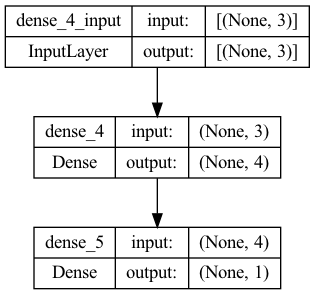

In [ ]:
# Visualize the model architecture
plot_model(model_test, show_shapes=True, show_layer_names=True)


## Lets build neural network with
* 2 hidden layer,
* Sigmoid function,
* Synthetic data
* Binary classification problem

In [ ]:
# Generate synthetic data
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Define the neural network architecture
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='sigmoid', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='sigmoid'),
    tf.keras.layers.Dense(16, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [ ]:
# Visualize the model architecture
def visualize_model(model):
    plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


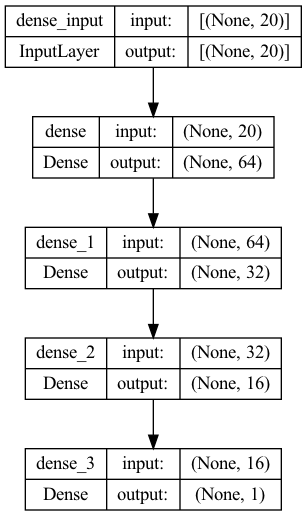

In [ ]:
# Visualize the model architecture
plot_model(model, to_file='architecture.png', show_shapes=True, show_layer_names=True)


In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)


Epoch 1/20
23/23 [==============================] - 0s 4ms/step - loss: 0.6955 - accuracy: 0.4917 - val_loss: 0.6885 - val_accuracy: 0.5750
Epoch 2/20
23/23 [==============================] - 0s 873us/step - loss: 0.6893 - accuracy: 0.5681 - val_loss: 0.6803 - val_accuracy: 0.7125
Epoch 3/20
23/23 [==============================] - 0s 930us/step - loss: 0.6782 - accuracy: 0.5903 - val_loss: 0.6674 - val_accuracy: 0.7000
Epoch 4/20
23/23 [==============================] - 0s 899us/step - loss: 0.6651 - accuracy: 0.7542 - val_loss: 0.6520 - val_accuracy: 0.8500
Epoch 5/20
23/23 [==============================] - 0s 926us/step - loss: 0.6435 - accuracy: 0.8208 - val_loss: 0.6232 - val_accuracy: 0.8250
Epoch 6/20
23/23 [==============================] - 0s 907us/step - loss: 0.6111 - accuracy: 0.8306 - val_loss: 0.5836 - val_accuracy: 0.8500
Epoch 7/20
23/23 [==============================] - 0s 955us/step - loss: 0.5669 - accuracy: 0.8347 - val_loss: 0.5296 - val_accuracy: 0.8500
Epoch 8/

In [ ]:
# Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 [==============================] - 0s 634us/step - loss: 0.3635 - accuracy: 0.8750
Test Loss: 0.3635256290435791
Test Accuracy: 0.875


## Adult income Kaggle Dataset Example

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import csv, os

In [6]:

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(z):       return 1 / (1 + np.exp(-z))
def relu(z):          return np.maximum(0, z)
def relu_d(z):        return (z > 0).astype(float)
def init(r, c):       return np.random.randn(r, c) * np.sqrt(2.0 / r)

def binary_cross_entropy(y, yhat, w=None):
    yhat = np.clip(yhat, 1e-9, 1 - 1e-9)
    loss = -(y * np.log(yhat) + (1 - y) * np.log(1 - yhat))
    return np.mean(loss if w is None else loss * w)

def forward(X, W1,b1,W2,b2,W3,b3):
    a1 = relu(X  @ W1 + b1)
    a2 = relu(a1 @ W2 + b2)
    yh = sigmoid(a2 @ W3 + b3)
    return a1, a2, yh

np.random.seed(42)

In [7]:
# ============================================================
# STEP 1 — DATA LOADING & PREPROCESSING
# ============================================================
# ★ Download from: https://www.kaggle.com/datasets/wenruliu/adult-income-dataset
# ★ Place the CSV in the same folder as this script, then set FILE_PATH below
FILE_PATH = "adult.csv"

# ---- Categorical encodings ----
WORKCLASS_MAP  = {"Private":0,"Self-emp-not-inc":1,"Self-emp-inc":2,
                  "Federal-gov":3,"Local-gov":4,"State-gov":5,
                  "Without-pay":6,"Never-worked":7}
EDUCATION_MAP  = {"Preschool":0,"1st-4th":1,"5th-6th":2,"7th-8th":3,
                  "9th":4,"10th":5,"11th":6,"12th":7,"HS-grad":8,
                  "Some-college":9,"Assoc-voc":10,"Assoc-acdm":11,
                  "Bachelors":12,"Masters":13,"Prof-school":14,"Doctorate":15}
MARITAL_MAP    = {"Married-civ-spouse":0,"Divorced":1,"Never-married":2,
                  "Separated":3,"Widowed":4,"Married-spouse-absent":5,
                  "Married-AF-spouse":6}
OCCUPATION_MAP = {"Tech-support":0,"Craft-repair":1,"Other-service":2,
                  "Sales":3,"Exec-managerial":4,"Prof-specialty":5,
                  "Handlers-cleaners":6,"Machine-op-inspct":7,"Adm-clerical":8,
                  "Farming-fishing":9,"Transport-moving":10,"Priv-house-serv":11,
                  "Protective-serv":12,"Armed-Forces":13}
RELATIONSHIP_MAP = {"Wife":0,"Own-child":1,"Husband":2,"Not-in-family":3,
                    "Other-relative":4,"Unmarried":5}
RACE_MAP       = {"White":0,"Asian-Pac-Islander":1,"Amer-Indian-Eskimo":2,
                  "Other":3,"Black":4}
SEX_MAP        = {"Male":0,"Female":1}
COUNTRY_MAP    = {"United-States":0,"Cuba":1,"Jamaica":2,"India":3,
                  "Mexico":4,"South":5,"Japan":6,"Philippines":7,
                  "Germany":8,"Puerto-Rico":9,"Canada":10,"El-Salvador":11,
                  "Other":12}

def encode_row(r):
    """Convert one CSV row dict → float feature vector. Returns None to skip."""
    try:
        vals = [
            float(r["age"]),
            float(WORKCLASS_MAP.get(r["workclass"].strip(), -1)),
            float(r["fnlwgt"]),
            float(EDUCATION_MAP.get(r["education"].strip(), -1)),
            float(r["educational-num"]),
            float(MARITAL_MAP.get(r["marital-status"].strip(), -1)),
            float(OCCUPATION_MAP.get(r["occupation"].strip(), -1)),
            float(RELATIONSHIP_MAP.get(r["relationship"].strip(), -1)),
            float(RACE_MAP.get(r["race"].strip(), -1)),
            float(SEX_MAP.get(r["gender"].strip(),
                  SEX_MAP.get(r.get("sex","").strip(), -1))),
            float(r["capital-gain"]),
            float(r["capital-loss"]),
            float(r["hours-per-week"]),
            float(COUNTRY_MAP.get(r.get("native-country","").strip(), 12)),
        ]
        if -1 in vals: return None, None
        label_raw = r.get("income","").strip().replace(".","")
        label = 1 if ">50K" in label_raw else 0
        return vals, label
    except (ValueError, KeyError):
        return None, None

def load_adult(path):
    X_raw, y_raw = [], []
    with open(path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            feats, label = encode_row(row)
            if feats is not None:
                X_raw.append(feats); y_raw.append(label)

    X = np.array(X_raw, dtype=float)
    y = np.array(y_raw, dtype=float).reshape(-1, 1)

    # Normalize
    mu = X.mean(0); sd = X.std(0) + 1e-8
    X  = (X - mu) / sd

    # Shuffle & split 80/20
    idx = np.random.permutation(len(X))
    s   = int(0.8 * len(X))
    return X[idx[:s]], y[idx[:s]], X[idx[s:]], y[idx[s:]]

# ---- Synthetic fallback (runs even without the CSV) ----
def make_synthetic(n=5000, n_feat=14):
    """Mimics adult income imbalance (~24% positive class)."""
    X  = np.random.randn(n, n_feat)
    # Positive (>50K) driven by features 0=age, 4=edu, 10=capital-gain
    score = 0.4*X[:,0] + 0.5*X[:,4] + 0.6*X[:,10] + np.random.randn(n)*0.8
    thresh = np.percentile(score, 76)   # ~24% positive
    y = (score >= thresh).astype(float).reshape(-1,1)
    mu=X.mean(0); sd=X.std(0)+1e-8; X=(X-mu)/sd
    s = int(0.8*n)
    return X[:s], y[:s], X[s:], y[s:]

if os.path.exists(FILE_PATH):
    X_tr, y_tr, X_te, y_te = load_adult(FILE_PATH)
    SYNTHETIC = False
    print(f"Loaded '{FILE_PATH}': {len(X_tr)+len(X_te)} rows")
else:
    X_tr, y_tr, X_te, y_te = make_synthetic()
    SYNTHETIC = True
    print(f"⚠  '{FILE_PATH}' not found — using synthetic data.\n"
          "   Download from: https://www.kaggle.com/datasets/wenruliu/adult-income-dataset")

n_feat = X_tr.shape[1]
pos_tr = y_tr.mean(); neg_tr = 1 - pos_tr
print(f"Train: {len(X_tr)} | Test: {len(X_te)}")
print(f"Class balance  →  ≤50K: {neg_tr*100:.1f}%   >50K: {pos_tr*100:.1f}%")


Loaded 'adult.csv': 46033 rows
Train: 36826 | Test: 9207
Class balance  →  ≤50K: 75.2%   >50K: 24.8%


In [8]:
# ============================================================
# STEP 2 — CLASS WEIGHTS  (key concept for imbalanced data!)
# ============================================================
# Penalise errors on the minority class (>50K) more heavily.
#   weight_pos = total / (2 * n_positive)
#   weight_neg = total / (2 * n_negative)
n_pos = y_tr.sum(); n_neg = len(y_tr) - n_pos
w_pos = len(y_tr) / (2 * n_pos)
w_neg = len(y_tr) / (2 * n_neg)
print(f"Class weights  →  ≤50K: {w_neg:.3f}   >50K: {w_pos:.3f}")

def sample_weights(y):
    """Return per-sample weight vector."""
    return np.where(y == 1, w_pos, w_neg)

Class weights  →  ≤50K: 0.665   >50K: 2.017


In [9]:

# ============================================================
# STEP 3 — MODEL:  n_feat → 64 (ReLU) → 32 (ReLU) → 1 (Sigmoid)
# ============================================================
W1=init(n_feat,64); b1=np.zeros((1,64))
W2=init(64,32);     b2=np.zeros((1,32))
W3=init(32,1);      b3=np.zeros((1,1))

LR, EPOCHS, BATCH = 0.01, 60, 256

tr_losses, te_losses = [], []
tr_accs,   te_accs   = [], []
tr_f1s,    te_f1s    = [], []

def f1_score(y_true, yhat, thresh=0.5):
    p = (yhat > thresh).astype(int).ravel()
    t = y_true.ravel().astype(int)
    tp = ((p==1)&(t==1)).sum()
    fp = ((p==1)&(t==0)).sum()
    fn = ((p==0)&(t==1)).sum()
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    return 2*prec*rec/(prec+rec+1e-9)

print(f"\nArchitecture: {n_feat} → 64 (ReLU) → 32 (ReLU) → 1 (Sigmoid)")
print(f"Loss: Weighted Binary Cross-Entropy | Optimizer: Mini-batch SGD")
print(f"Epochs: {EPOCHS} | Batch: {BATCH} | LR: {LR}\n")

for epoch in range(EPOCHS):
    perm = np.random.permutation(len(X_tr))
    for i in range(0, len(X_tr), BATCH):
        idx = perm[i:i+BATCH]
        Xb, yb = X_tr[idx], y_tr[idx]
        wb = sample_weights(yb)           # (B,1) sample weights

        # ---- Forward (store z values for backprop) ----
        z1=Xb@W1+b1; a1=relu(z1)
        z2=a1@W2+b2; a2=relu(z2)
        yh=sigmoid(a2@W3+b3)

        # ---- Weighted BCE gradient ----
        # dL/dz_out = (yhat - y) * sample_weight / batch_size
        dz3 = (yh - yb) * wb / len(yb)
        dW3=a2.T@dz3;  db3=np.sum(dz3,0)
        dz2=(dz3@W3.T)*relu_d(z2)
        dW2=a1.T@dz2;  db2=np.sum(dz2,0)
        dz1=(dz2@W2.T)*relu_d(z1)
        dW1=Xb.T@dz1;  db1=np.sum(dz1,0)

        W3-=LR*dW3; b3-=LR*db3
        W2-=LR*dW2; b2-=LR*db2
        W1-=LR*dW1; b1-=LR*db1

    # ---- Epoch metrics ----
    _,_,yh_tr = forward(X_tr, W1,b1,W2,b2,W3,b3)
    _,_,yh_te = forward(X_te, W1,b1,W2,b2,W3,b3)
    wtr = sample_weights(y_tr)

    tr_losses.append(binary_cross_entropy(y_tr, yh_tr, wtr))
    te_losses.append(binary_cross_entropy(y_te, yh_te, sample_weights(y_te)))
    tr_accs.append(np.mean((yh_tr>0.5)==y_tr))
    te_accs.append(np.mean((yh_te>0.5)==y_te))
    tr_f1s.append(f1_score(y_tr, yh_tr))
    te_f1s.append(f1_score(y_te, yh_te))

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  "
              f"Train → Loss:{tr_losses[-1]:.4f} Acc:{tr_accs[-1]*100:.1f}% F1:{tr_f1s[-1]:.3f} | "
              f"Test  → Loss:{te_losses[-1]:.4f} Acc:{te_accs[-1]*100:.1f}% F1:{te_f1s[-1]:.3f}")



Architecture: 14 → 64 (ReLU) → 32 (ReLU) → 1 (Sigmoid)
Loss: Weighted Binary Cross-Entropy | Optimizer: Mini-batch SGD
Epochs: 60 | Batch: 256 | LR: 0.01

Epoch  10/60  Train → Loss:0.4131 Acc:78.7% F1:0.663 | Test  → Loss:0.4186 Acc:78.7% F1:0.667
Epoch  20/60  Train → Loss:0.3980 Acc:79.4% F1:0.671 | Test  → Loss:0.4052 Acc:79.4% F1:0.674
Epoch  30/60  Train → Loss:0.3917 Acc:79.6% F1:0.675 | Test  → Loss:0.4001 Acc:79.7% F1:0.678
Epoch  40/60  Train → Loss:0.3884 Acc:79.2% F1:0.673 | Test  → Loss:0.3976 Acc:79.5% F1:0.679
Epoch  50/60  Train → Loss:0.3864 Acc:80.0% F1:0.679 | Test  → Loss:0.3959 Acc:80.2% F1:0.683
Epoch  60/60  Train → Loss:0.3845 Acc:79.7% F1:0.677 | Test  → Loss:0.3947 Acc:79.9% F1:0.681


In [10]:

# ============================================================
# STEP 4 — FINAL EVALUATION
# ============================================================
_,_,yh_final = forward(X_te, W1,b1,W2,b2,W3,b3)
pred = (yh_final > 0.5).astype(int).ravel()
true = y_te.ravel().astype(int)

tp=((pred==1)&(true==1)).sum(); fp=((pred==1)&(true==0)).sum()
tn=((pred==0)&(true==0)).sum(); fn=((pred==0)&(true==1)).sum()
prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
f1   = 2*prec*rec/(prec+rec+1e-9)
spec = tn/(tn+fp+1e-9)

print(f"\n{'─'*50}")
print(f"  Final Test Results {'(Synthetic)' if SYNTHETIC else '(Adult Income)'}")
print(f"{'─'*50}")
print(f"  Accuracy : {np.mean(pred==true)*100:.2f}%")
print(f"  Precision: {prec:.4f}   (of predicted >50K, how many are correct)")
print(f"  Recall   : {rec:.4f}   (of actual >50K, how many did we catch)")
print(f"  F1 Score : {f1:.4f}   (harmonic mean of precision & recall)")
print(f"  Specificity: {spec:.4f} (of actual ≤50K, how many correctly identified)")
print(f"\n  Confusion Matrix:")
print(f"                 Predicted ≤50K   Predicted >50K")
print(f"  Actual ≤50K       {tn:>6}           {fp:>6}")
print(f"  Actual >50K       {fn:>6}           {tp:>6}")



──────────────────────────────────────────────────
  Final Test Results (Adult Income)
──────────────────────────────────────────────────
  Accuracy : 79.86%
  Precision: 0.5620   (of predicted >50K, how many are correct)
  Recall   : 0.8647   (of actual >50K, how many did we catch)
  F1 Score : 0.6812   (harmonic mean of precision & recall)
  Specificity: 0.7767 (of actual ≤50K, how many correctly identified)

  Confusion Matrix:
                 Predicted ≤50K   Predicted >50K
  Actual ≤50K         5372             1544
  Actual >50K          310             1981


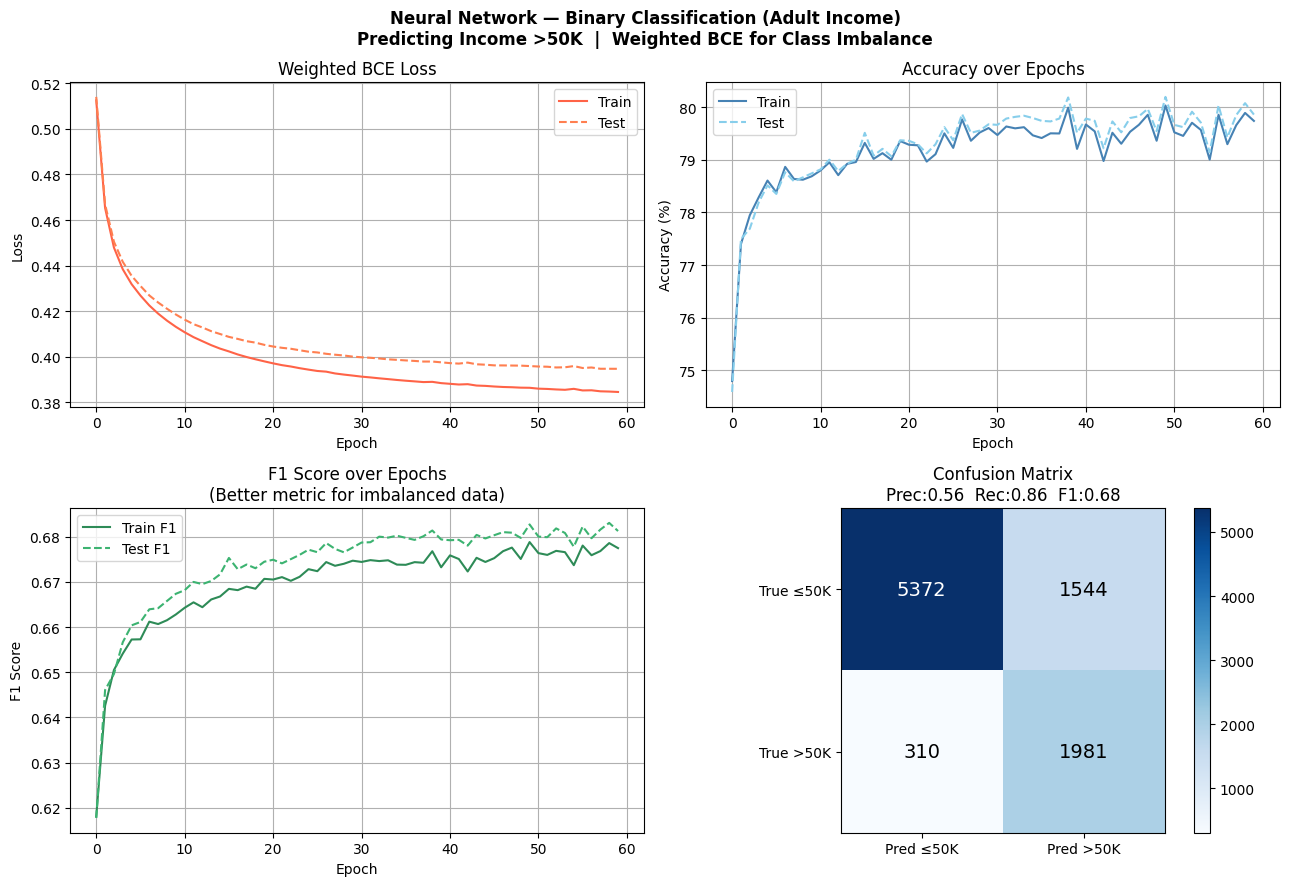


★ Key takeaway: On imbalanced data, high Accuracy can be misleading.
  A naive model predicting ≤50K always would score ~75% accuracy!
  F1 Score (0.681) tells the real story.


In [11]:

# ============================================================
# STEP 5 — PLOTS
# ============================================================
sfx = "(Synthetic)" if SYNTHETIC else "(Adult Income)"
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"Neural Network — Binary Classification {sfx}\n"
             f"Predicting Income >50K  |  Weighted BCE for Class Imbalance",
             fontsize=12, fontweight='bold')

# Loss
axes[0,0].plot(tr_losses, label='Train', color='tomato')
axes[0,0].plot(te_losses, label='Test',  color='coral', linestyle='--')
axes[0,0].set_title("Weighted BCE Loss"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss"); axes[0,0].legend(); axes[0,0].grid(True)

# Accuracy
axes[0,1].plot([a*100 for a in tr_accs], label='Train', color='steelblue')
axes[0,1].plot([a*100 for a in te_accs], label='Test',  color='skyblue', linestyle='--')
axes[0,1].set_title("Accuracy over Epochs"); axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Accuracy (%)"); axes[0,1].legend(); axes[0,1].grid(True)

# F1 Score
axes[1,0].plot(tr_f1s, label='Train F1', color='seagreen')
axes[1,0].plot(te_f1s, label='Test F1',  color='mediumseagreen', linestyle='--')
axes[1,0].set_title("F1 Score over Epochs\n(Better metric for imbalanced data)")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("F1 Score")
axes[1,0].legend(); axes[1,0].grid(True)

# Confusion matrix
cm = np.array([[tn, fp],[fn, tp]])
im = axes[1,1].imshow(cm, cmap='Blues')
axes[1,1].set_xticks([0,1]); axes[1,1].set_yticks([0,1])
axes[1,1].set_xticklabels(["Pred ≤50K","Pred >50K"])
axes[1,1].set_yticklabels(["True ≤50K","True >50K"])
axes[1,1].set_title(f"Confusion Matrix\nPrec:{prec:.2f}  Rec:{rec:.2f}  F1:{f1:.2f}")
for i in range(2):
    for j in range(2):
        axes[1,1].text(j, i, cm[i,j], ha='center', va='center', fontsize=14,
                       color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[1,1])
plt.tight_layout(); plt.savefig("adult_income_nn.png", dpi=100); plt.show()

print("\n★ Key takeaway: On imbalanced data, high Accuracy can be misleading.")
print(f"  A naive model predicting ≤50K always would score ~{neg_tr*100:.0f}% accuracy!")
print(f"  F1 Score ({f1:.3f}) tells the real story.")

When the model misclassifies a >50K person (minority), wb = 2.0 so the gradient is twice as large — meaning the weights get a bigger correction nudge during backpropagation. The model is literally penalised more and forced to pay attention.